In [1]:
import scanpy as sc
import hdf5plugin
import anndata as ad

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn.objects  as so
import seaborn as sns

from scipy.stats import chi2_contingency, false_discovery_control, mannwhitneyu
from scipy.stats import pearsonr,spearmanr
from sklearn.metrics import mean_squared_error, r2_score

import decoupler as dc
import os

from tqdm import tqdm

In [2]:
import importlib
importlib.reload(dc)

<module 'decoupler' from '/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/decoupler/__init__.py'>

In [2]:
import plotting_funs
prop_cycle = plotting_funs.set_mpl_attributes()

# Load Data:

In [3]:
def ctrl_pert_split_dataset(norm_data: ad.AnnData) -> tuple[list[str], dict[str,list[str]]]:
    # Split df into perturbed and control cells
    by_pert = [pert for _, pert in norm_data.obs.groupby(norm_data.obs["perturbation"])]
    # Find indices for each perturbation
    pert_i_dict = {pert.iloc[0]["perturbation"]:pert.index.to_list() for pert in by_pert}
    # Extract the control cells separately
    ctrl_i_vec = pert_i_dict.pop("ctrl")
    return (ctrl_i_vec, pert_i_dict)

In [4]:
grn_file = "KeggoRo_noG"
names = ["Norman19","Replogle22"]
models = ["experimental","pGRiNS"]#, "Random"]

models_rand = ["pGRiNS","Random"]

In [6]:
data = {}
for name in names:
    data[name] = {}
    for model in models:
        data[name][model] = {}
    data[name]["experimental"]["adata"] = sc.read_h5ad(f"../Data/Experimental/{name}/perturb_norm_subset_{grn_file}.h5ad")
    #perts = list(data[name]["experimental"]["adata"].obs["perturbation"].unique())[:10]
    #data[name]["experimental"]["adata"] = data[name]["experimental"]["adata"][data[name]["experimental"]["adata"].obs["perturbation"].isin(["ctrl"]+perts)]

pgrins_full = sc.read_h5ad(f"../Data/Projects/{grn_file}/001/perturb_norm_full.h5ad")
data["Norman19"]["pGRiNS"]["adata"] = pgrins_full[pgrins_full.obs["PertNum"].isin(data["Norman19"]["experimental"]["adata"].obs["PertNum"]),sorted(list(set(data["Norman19"]["experimental"]["adata"].var_names)&set(pgrins_full.var_names)))]
data["Replogle22"]["pGRiNS"]["adata"] = pgrins_full[pgrins_full.obs["PertNum"].isin(data["Replogle22"]["experimental"]["adata"].obs["PertNum"]),sorted(list(set(data["Replogle22"]["experimental"]["adata"].var_names)&set(pgrins_full.var_names)))]

for name in names:
    data[name]["experimental"]["adata"] = data[name]["experimental"]["adata"][:,sorted(list(set(data[name]["experimental"]["adata"].var_names)&set(data[name]["pGRiNS"]["adata"].var_names)))]
    data[name]["perts"] = list(data[name]["experimental"]["adata"].obs["perturbation"].unique())
    data[name]["perts"].remove("ctrl")
    for model in models:
        data[name][model]["pert_indices"] = ctrl_pert_split_dataset(data[name][model]["adata"])
        data[name][model]["pert_means"] = {pert : np.asarray(np.mean(data[name][model]["adata"][data[name][model]["pert_indices"][1][pert]].layers["log1p"],axis=0)).squeeze() for pert in tqdm(data[name]["perts"])}

/tmp/ipykernel_292461/3870400248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_pert = [pert for _, pert in norm_data.obs.groupby(norm_data.obs["perturbation"])]
100%|██████████| 24/24 [00:11<00:00,  2.10it/s]
/tmp/ipykernel_292461/3870400248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_pert = [pert for _, pert in norm_data.obs.groupby(norm_data.obs["perturbation"])]
100%|██████████| 24/24 [00:03<00:00,  6.20it/s]
/tmp/ipykernel_292461/3870400248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to 

# Qualitative comparison:

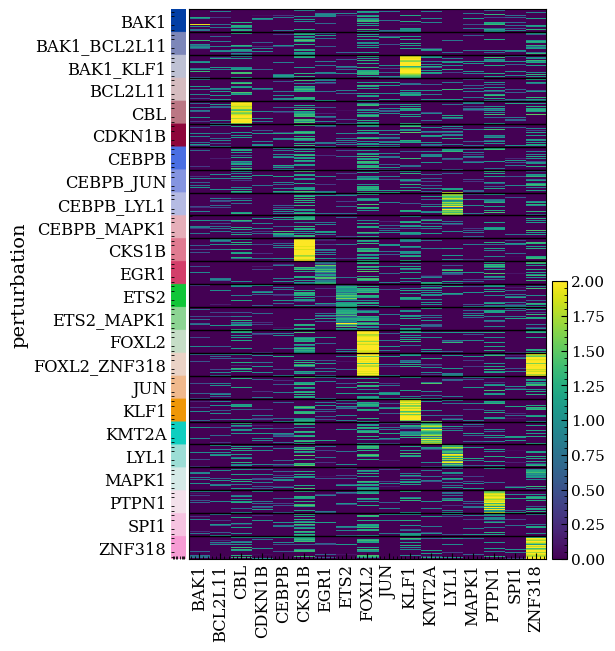

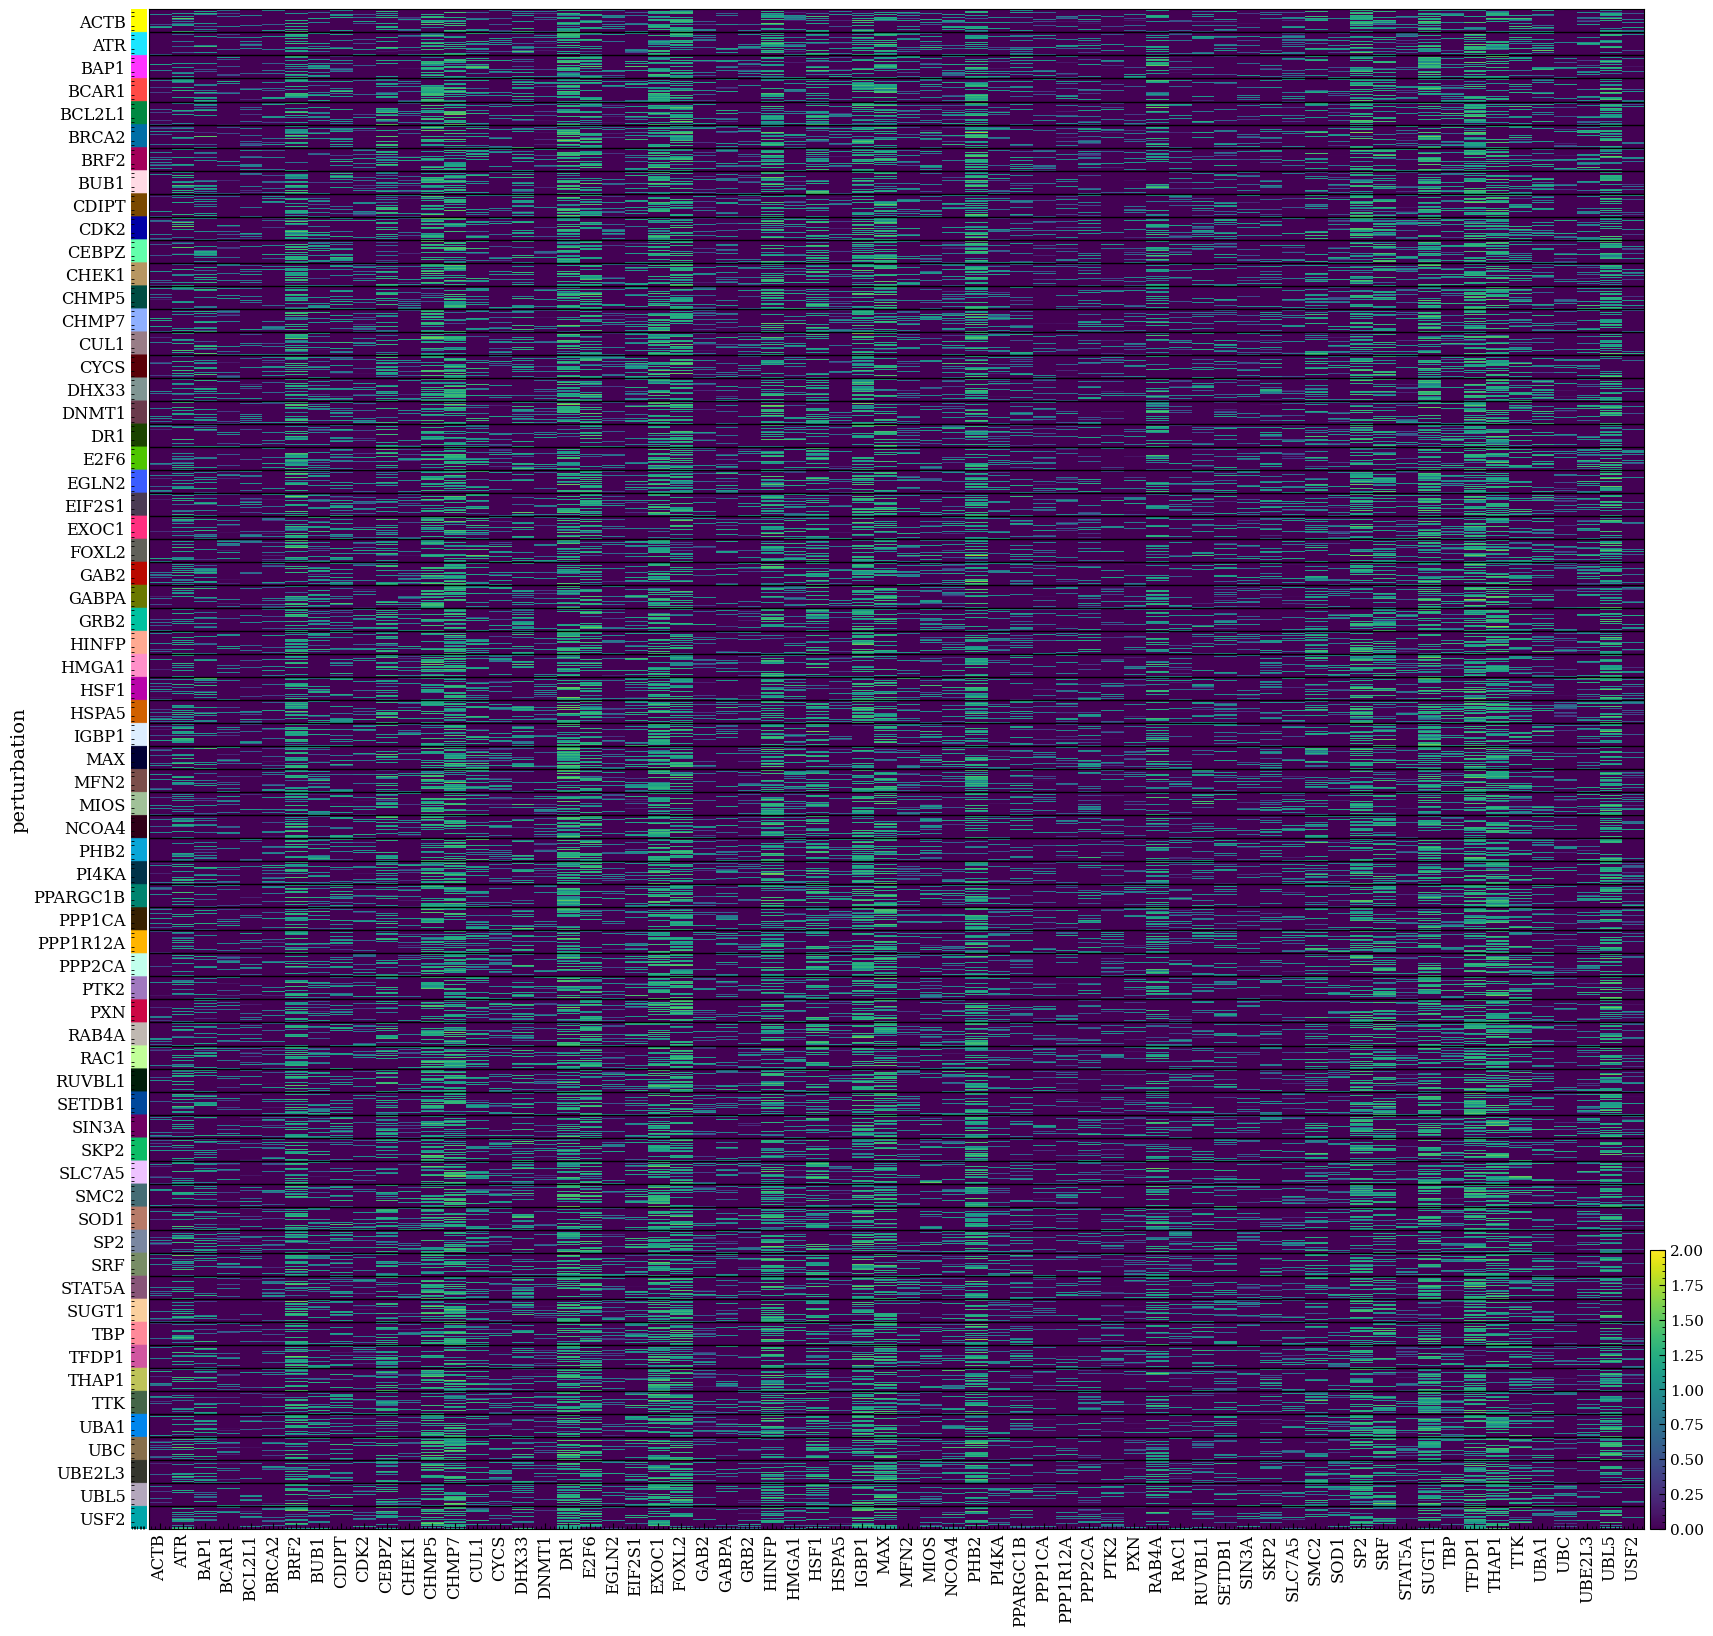

In [22]:
for name in names:
    pgenes = set().union(*[set(p.split("_")) for p in data[name]["perts"]])
    sc.pl.heatmap(data[name]["pGRiNS"]["adata"][data[name]["pGRiNS"]["adata"].obs["perturbation"]!="ctrl"],sorted(list(pgenes)),"perturbation",layer="log1p",vmax=2,show_gene_labels=True,figsize=(0.3*len(pgenes),0.3*len(data[name]["perts"])))

# Shared DEGs:

In [8]:
for name in names:
    for model in models:
        sc.tl.rank_genes_groups(data[name][model]["adata"],groupby="perturbation",reference="rest",key_added="DEG_analysis",rankby_abs=True,layer="log1p")
        data[name][model]["DEGs"] = {pert : data[name][model]["adata"].uns["DEG_analysis"]["names"][pert][data[name][model]["adata"].uns["DEG_analysis"]["pvals_adj"][pert] < 0.05] for pert in tqdm(data[name]["perts"])}
        #data[name][model]["ON_genes"] = {pert : data[name][model]["adata"].var_names[data[name][model]["pert_means"][pert]>np.mean(data[name][model]["pert_means"][pert])] for pert in tqdm(data[name]["perts"])}
    data[name]["Random"] = {}
    data[name]["Random"]["DEGs"] = {pert: np.random.choice(list(data[name]["pGRiNS"]["adata"].var_names),size=len(data[name]["pGRiNS"]["DEGs"][pert])) for pert in tqdm(data[name]["perts"])}
    #data[name]["Random"]["ON_genes"] = {pert: np.random.choice(list(data[name]["pGRiNS"]["adata"].var_names),size=len(data[name]["pGRiNS"]["ON_genes"][pert])) for pert in tqdm(data[name]["perts"])}

/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:679: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-

In [9]:
chisq_res = {}
for test in ["DEGs"]:#,"ON_genes"]:
    chisq_res[test] = {}
    for model in ["pGRiNS","Random"]:
        chisq_res[test][model] = {}
        chisq_res[test][model]["pvals"] = []
        for name in names:
            for pert in data[name]["perts"]:
                genes_exp_set = set(data[name]["experimental"][test][pert])
                all_genes = set(data[name]["experimental"]["adata"].var_names)
                genes_model_set = set(data[name][model][test][pert])
                # Get contingency matrix
                count_matrix = np.array([[len(genes_exp_set & genes_model_set),len(genes_model_set - genes_exp_set)],[len(genes_exp_set - genes_model_set),len(all_genes - (genes_exp_set|genes_model_set))]])
                res = chi2_contingency(count_matrix)
                chisq_res[test][model]["pvals"].append(res.pvalue)
        chisq_res[test][model]["pvals_adj"] = false_discovery_control(chisq_res[test][model]["pvals"]) # Benjamini-Hochberg correction due to large number of p values
        


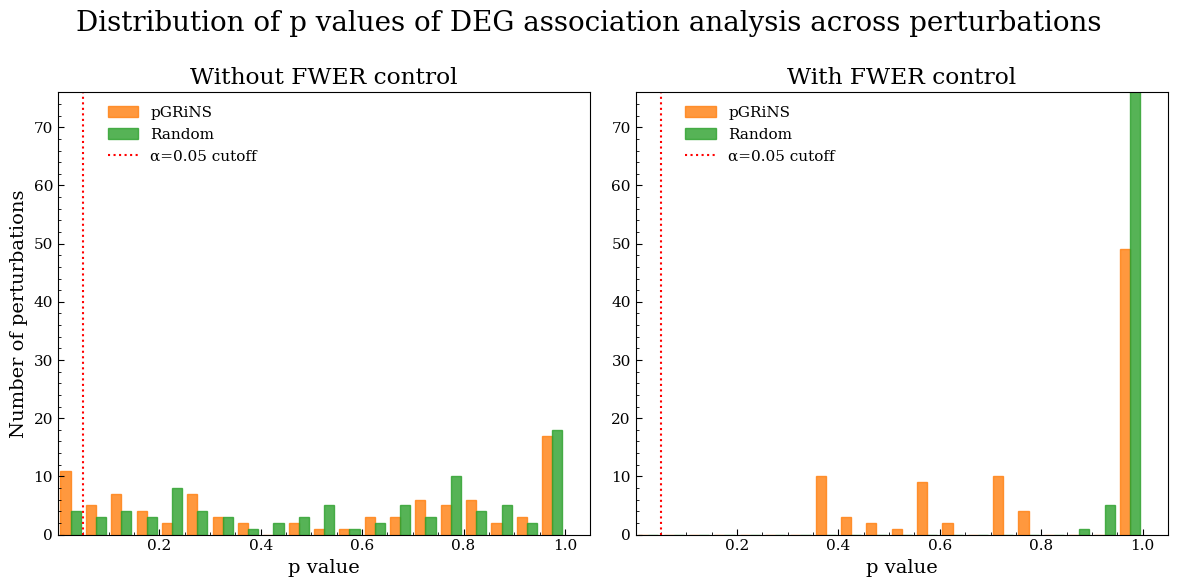

In [26]:
fig, axs = plt.subplots(1,2,figsize=(12,6))
axs[0].hist([chisq_res["DEGs"]["pGRiNS"]["pvals"],chisq_res["DEGs"]["Random"]["pvals"]],bins=20,label=["pGRiNS","Random"],range=(0,1),color=[prop_cycle[1],prop_cycle[2]],alpha=0.8,lw=1,edgecolor=[prop_cycle[1],prop_cycle[2]])
axs[0].vlines(0.05,0,76,color="red",linestyles="dotted",label="α=0.05 cutoff")
axs[0].set_ylim(0,76)
axs[0].set_xlim(0.000001,1.05)
axs[0].set_title("Without FWER control")
axs[0].legend(bbox_to_anchor=(0.4,1))
axs[0].set_ylabel("Number of perturbations")
axs[0].set_xlabel("p value")

axs[1].hist([chisq_res["DEGs"]["pGRiNS"]["pvals_adj"],chisq_res["DEGs"]["Random"]["pvals_adj"]],label=["pGRiNS","Random"],bins=20,range=(0,1),color=[prop_cycle[1],prop_cycle[2]],alpha=0.8,lw=1,edgecolor=[prop_cycle[1],prop_cycle[2]])
axs[1].vlines(0.05,0,76,color="red",linestyles="dotted",label="α=0.05 cutoff")
axs[1].set_ylim(0,76)
axs[1].set_xlim(0.0000001,1.05)
axs[1].set_title("With FWER control")
axs[1].legend(bbox_to_anchor=(0.4,1))
axs[1].set_xlabel("p value")
fig.suptitle("Distribution of p values of DEG association analysis across perturbations")
fig.tight_layout()
os.makedirs(f"Plots/{grn_file}/001",exist_ok=True)
plt.savefig(f"Plots/{grn_file}/001/DEG_pvals.svg")
plt.show()

In [ ]:
u_deg = mannwhitneyu(chisq_res["DEGs"]["pGRiNS"]["pvals_adj"],chisq_res["DEGs"]["Random"]["pvals_adj"],alternative="less")
print(u_deg.pvalue) # 1.5952434146912225e-10

1.5952434146912225e-10


# Compare using metrics:

In [12]:
for name in names:
    for model in models:
        sc.tl.rank_genes_groups(data[name][model]["adata"],groupby="perturbation",reference="rest",key_added="DEG_analysis_Mejia",method="t-test_overestim_var",layer="log1p")
    
        data[name][model]["weights_Mejia"] = {}
        for pert in data[name]["perts"]:
            pert_weights = data[name][model]["adata"].uns["DEG_analysis_Mejia"]["scores"][pert]
            pert_weights = np.abs(pert_weights) # Absolute value transformation
            pert_weights = (pert_weights-min(pert_weights))/(max(pert_weights)-min(pert_weights)+1e-8) # Min-max transformation to [0,1]
            pert_weights = pert_weights**2 # Squaring
            pert_weights = pert_weights/sum(pert_weights) # Normalization
            pert_weights = pert_weights[np.argsort(data[name][model]["adata"].uns["DEG_analysis_Mejia"]["names"][pert])] # Bring them in the correct order (so that the corresponding genes are ordered alphabetically)
            data[name][model]["weights_Mejia"][pert] = pert_weights
        

/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:462: PerformanceWarning: Da

In [13]:
metrics = {
    "MSE\n(↓)":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed,weights : mean_squared_error(avg_expr_GT_pert, avg_expr_pred),
    "wMSE\n(↓)":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed, weights: np.dot(weights,(avg_expr_GT_pert-avg_expr_pred)**2),
    "Pearson\n(↑)":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed,weights : pearsonr(x=avg_expr_GT_pert, y=avg_expr_pred).correlation,
    "Pearson Delta\n(↑)":lambda avg_expr_GT_pert,avg_expr_pred, mean_unperturbed,weights : 0.0 if (avg_expr_pred == mean_unperturbed).all() else pearsonr(x=avg_expr_GT_pert-mean_unperturbed, y=avg_expr_pred-mean_unperturbed).correlation,
    "Weighted Delta R2\n(↑)":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed, weights: 1-(np.dot(weights,(avg_expr_GT_pert-avg_expr_pred)**2))/(np.dot(weights,(avg_expr_GT_pert-mean_unperturbed-np.dot(weights,(avg_expr_GT_pert-mean_unperturbed)))**2)) # 0.0 if (avg_expr_pred == mean_unperturbed).all() else 
    }

metric_names = list(metrics.keys())
#metric_names = metric_names[:4]

In [14]:
# For every perturbation: calculate the WMSE between the experimental data mean and each cell of the model
cellwise_metric = {}
for name in names:
    print(name)
    cellwise_metric[name] = {}
    for model in models:
        exp_pert_mean = np.mean(np.vstack(list(data[name][model]["pert_means"].values())),axis=0) # µ_all
        print(model)
        cellwise_metric[name][model] = {}
        for m in metric_names:
            print(m)
            cellwise_metric[name][model][m] = []
            for pert in tqdm(data[name]["perts"]):
                cell_mean = np.mean(data[name][model]["adata"][data[name][model]["pert_indices"][1][pert]].layers["log1p"].todense(),axis=0)
                m_mean = metrics[m](data[name]["experimental"]["pert_means"][pert],np.asarray(cell_mean).squeeze(),exp_pert_mean,data[name][model]["weights_Mejia"][pert])
                cellwise_metric[name][model][m].append(m_mean)
    # Negative baseline: WMSE between each experimental control cell and the experimental data mean
    cellwise_metric[name]["ctrl_baseline"] = {}
    print("ctrl_baseline")
    control_mean = np.mean(data[name]["experimental"]["adata"][data[name]["experimental"]["pert_indices"][0]].layers["log1p"].todense(),axis=0)
    for m in metric_names:
        print(m)
        cellwise_metric[name]["ctrl_baseline"][m] = []
        for pert in tqdm(data[name]["perts"]):
            m_mean = metrics[m](data[name]["experimental"]["pert_means"][pert],np.asarray(control_mean).squeeze(),exp_pert_mean,data[name][model]["weights_Mejia"][pert])
            cellwise_metric[name]["ctrl_baseline"][m].append(m_mean)

# Hypothesis: all normally distributed, mu_p,exp < mu_p,pgrins << mu_c,exp

# is the order of pval_adj or t score alphabetically? Or are they reordered according to pval?

Norman19
experimental
MSE
(↓)


100%|██████████| 24/24 [00:04<00:00,  5.16it/s]


wMSE
(↓)


100%|██████████| 24/24 [00:04<00:00,  5.43it/s]


Pearson
(↑)


...

100%|██████████| 66/66 [00:00<00:00, 900.75it/s]


Pearson Delta
(↑)


100%|██████████| 66/66 [00:00<00:00, 1122.73it/s]


Weighted Delta R2
(↑)


100%|██████████| 66/66 [00:00<00:00, 10140.45it/s]


In [15]:
#+cellwise_metric["Replogle22"]["ctrl_baseline"][m]
#+cellwise_metric["Replogle22"]["pGRiNS"][m]

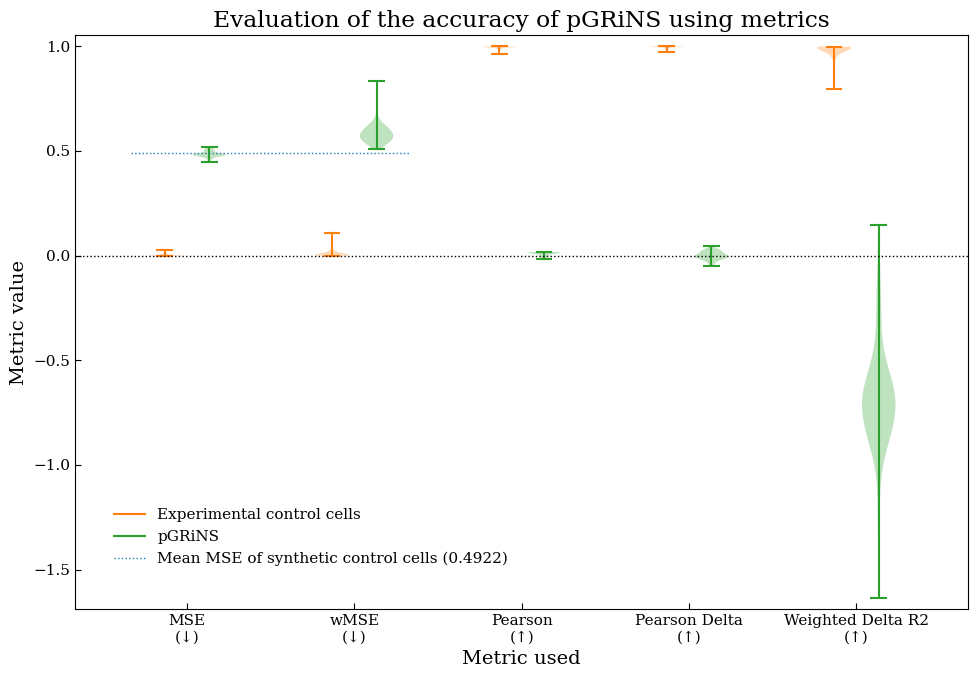

In [30]:
def set_box_color(bp, color):
    plt.setp(bp['boxes'], color=color)
    plt.setp(bp['whiskers'], color=color)
    plt.setp(bp['caps'], color=color)
    plt.setp(bp['medians'], color=color)
plt.figure(figsize=(2*len(metric_names),7))
plt.plot([])
bpr = plt.violinplot([cellwise_metric["Norman19"]["ctrl_baseline"][m]+cellwise_metric["Replogle22"]["ctrl_baseline"][m] for m in metric_names],positions=np.array(np.arange(len(metric_names)))*3.0-0.4, widths=0.6)
bpl = plt.violinplot([cellwise_metric["Norman19"]["pGRiNS"][m]+cellwise_metric["Replogle22"]["pGRiNS"][m] for m in metric_names],positions=np.array(np.arange(len(metric_names)))*3.0+0.4, widths=0.6)

plt.plot([], c=prop_cycle[1], label='Experimental control cells')
plt.plot([], c=prop_cycle[2], label='pGRiNS')
plt.hlines(0,-3, len(metric_names) * 3,linestyles="dotted",lw=1,color="black")
mse = 0.49218434
plt.hlines(0.49218434,-1, 4,linestyles="dotted",lw=1,color=prop_cycle[0],label=f"Mean MSE of synthetic control cells ({np.round(mse,4)})")
plt.legend(bbox_to_anchor=(0.5,0.2))
#set_box_color(bpl, prop_cycle[0])
#set_box_color(bpr, prop_cycle[1])
#plt.ylim(-1,1)import plotting_funs
plt.xticks(range(0, len(metric_names) * 3, 3),metric_names)# [metric_names[0]+" (↓)",metric_names[1]+" (↓)",metric_names[2]+" (↑)"])
plt.tick_params(which='minor', length=0)
plt.xlim(-3+1, len(metric_names)*3-1)
plt.title("Evaluation of the accuracy of pGRiNS using metrics")
plt.xlabel("Metric used")
plt.ylabel("Metric value")
plt.tight_layout()
plt.savefig(f"Plots/{grn_file}/001/metrics.svg")
plt.show()

# Pathways:

## GSEA:

- Inspired from https://www.sc-best-practices.org/conditions/gsea_pathway.html

In [17]:
# Retrieving via python
msigdb = dc.op.resource("MSigDB")

# Get reactome pathways
reactome = msigdb.query("collection == 'reactome_pathways'")
# Filter duplicates
reactome = reactome[~reactome.duplicated(("geneset", "genesymbol"))].rename(columns={"genesymbol":"target","geneset":"source"})

In [18]:
gsea_dict = {}
for name in names:
    gsea_dict[name] = {}
    # Filter reactome by genes in each dataset
    gsea_dict[name]["reactome"] = reactome[reactome["target"].isin(data[name]["experimental"]["adata"].var_names)]
    # Get the genesets with no. of genes in [15,500]
    geneset_size = gsea_dict[name]["reactome"].groupby("source").size()
    gsea_dict[name]["genesets"] = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)] # ~600 genesets for both datasets
    for model in models:
        gsea_dict[name][model] = {}
        for pert in tqdm(data[name]["perts"]):
            t_stats = sc.get.rank_genes_groups_df(data[name][model]["adata"], pert, key="DEG_analysis").set_index("names").sort_values("scores", key=np.abs, ascending=False)[["scores"]].rename_axis([pert], axis=1)
            scores, pvals = dc.mt.gsea(
                t_stats.T,
                gsea_dict[name]["reactome"][gsea_dict[name]["reactome"]["source"].isin(gsea_dict[name]["genesets"])],
            )
            gsea_dict[name][model][pert] = (
                pd.concat({"score": scores.T, "pval": pvals.T}, axis=1)
                .droplevel(level=1, axis=1)
                .sort_values("pval")
            )

100%|██████████| 66/66 [08:16<00:00,  7.53s/it]


/tmp/ipykernel_12368/4198627778.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  gsea_pearsons.append(pearsonr(gsea_dict[name]["experimental"][pert].sort_index().pval,gsea_dict[name]["pGRiNS"][pert].sort_index().pval).correlation)


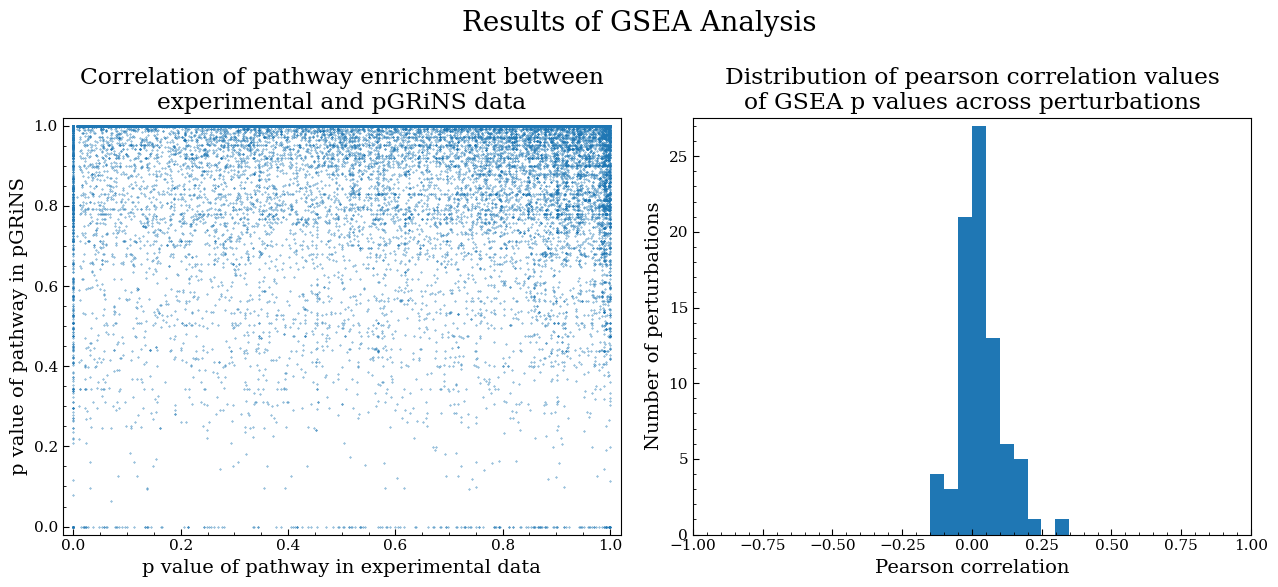

In [31]:
gsea_pearsons = []
fig,axs=plt.subplots(1,2,figsize=(13,6))
for name in names:
    for pert in data[name]["perts"]:            
        gsea_pearsons.append(pearsonr(gsea_dict[name]["experimental"][pert].sort_index().pval,gsea_dict[name]["pGRiNS"][pert].sort_index().pval).correlation)
        axs[0].scatter(gsea_dict[name]["experimental"][pert].sort_index().pval,gsea_dict[name]["pGRiNS"][pert].sort_index().pval,s=0.1,c=prop_cycle[0])
    axs[0].set_ylabel("p value of pathway in pGRiNS")
    axs[0].set_xlabel("p value of pathway in experimental data")
    axs[0].set_title("Correlation of pathway enrichment between\nexperimental and pGRiNS data")
    axs[1].hist(gsea_pearsons,bins=10,color=prop_cycle[0])
    axs[1].set_xlim(-1,1)
    axs[1].set_title("Distribution of pearson correlation values\nof GSEA p values across perturbations")
    axs[1].set_ylabel("Number of perturbations")
    axs[1].set_xlabel("Pearson correlation")
#axs[0].scatter(gsea_dict["Replogle22"]["experimental"]["RPS27A"].sort_index().pval,gsea_dict["Replogle22"]["pGRiNS"]["RPS27A"].sort_index().pval,s=1,c=prop_cycle[1])
fig.suptitle("Results of GSEA Analysis")
fig.tight_layout()
plt.savefig(f"Plots/{grn_file}/001/gsea.svg")
# RPS27A is outlier
plt.show()

## Coexpression Graph:
- Inspired from https://link.springer.com/protocol/10.1007/978-1-0716-2067-0_19

- Both GO analysis on modules, and graph comparison with CoDiNA
    - GSEA is done perturbation wise (can pGRiNS capture the specific pathways affected by a perturbation?)
    - GO is done across perturbations (are genes generally coexpressed in such a way that networks/pathways are derivable?   )

In [20]:
# Prepare data for original GRN:
full_topo = pd.read_csv(f"../Data/Projects/{grn_file}/{grn_file}_full.topo",sep=" ").loc[:,["Source","Target"]]
full_topo["wTO"] = 1

for name in names:
    for model in models:
        pert_mean_matrix = pd.DataFrame(np.vstack(list(data[name][model]["pert_means"].values())),columns=data[name][model]["adata"].var_names)
        pert_mean_matrix.to_csv(f"../Data/Experimental/{name}/{name}-{model}_pert_mean.csv",sep=" ",index=False)
    genes = data[name][model]["adata"].var_names
    genes_dict = {genes[i]:i for i in range(len(genes))}
    full_topo_dataset = full_topo[(full_topo["Source"].isin(genes))&full_topo["Target"].isin(genes)]
    adj = np.eye(len(genes)).astype(bool)
    for i, row in full_topo_dataset.iterrows():
        adj[genes_dict[row["Source"]],genes_dict[row["Target"]]] = True
        adj[genes_dict[row["Target"]],genes_dict[row["Source"]]] = True
    full_topo_dataset.to_csv(f"../Data/Projects/{grn_file}/wTO_{name}.csv",index=False)
    pd.DataFrame(adj,columns=data[name][model]["adata"].var_names).to_csv(f"../Data/Projects/{grn_file}/adj_{name}.csv",index=False)


# Used as input in coexpr.R

In [7]:
for name in names:
    data[name]["diffnet_edges"] = pd.read_csv(f"diffnet_edges_{name}.csv",sep=" ")
    data[name]["diffnet_genes"] = pd.read_csv(f"diffnet_genes_{name}.csv",sep=" ")
    data[name]["confusion_matrix_pGRiNS"] = pd.read_csv(f"conf_mat{name}_pGRiNS.csv",sep=" ",index_col=-1)
    data[name]["confusion_matrix_GRN"] = pd.read_csv(f"conf_mat{name}_GRN.csv",sep=" ",index_col=-1)

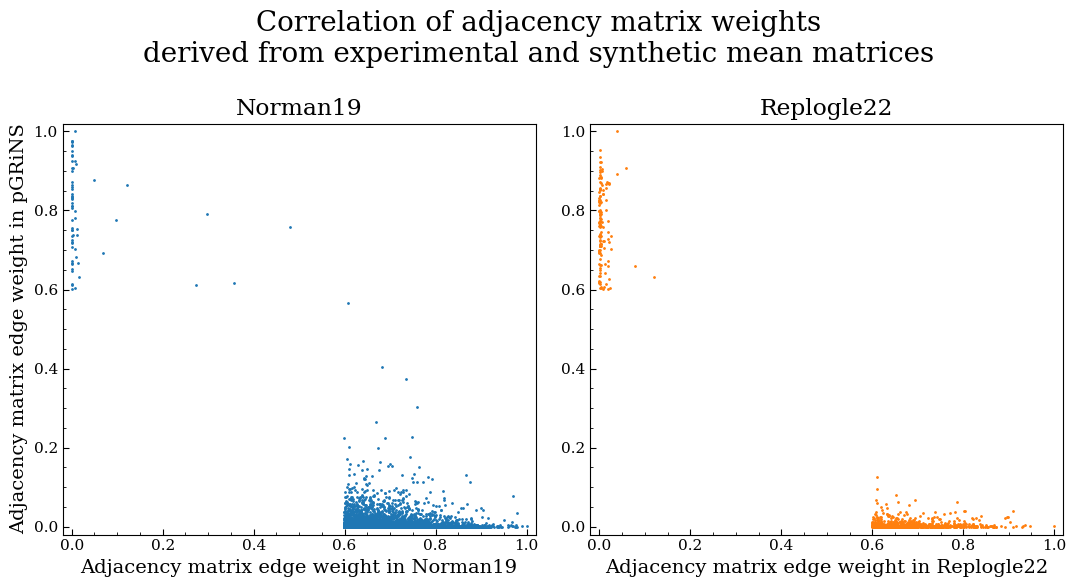

In [91]:
fig, axs = plt.subplots(1,2,figsize=(11,6))
for i in range(2):
    axs[i].scatter(data[names[i]]["diffnet_edges"]["diff_net.experimental"],data[names[i]]["diffnet_edges"]["diff_net.pGRiNS"],c=prop_cycle[i],s=1)
    axs[i].set_title(names[i])
    axs[i].set_xlabel(f"Adjacency matrix edge weight in {names[i]}")
axs[0].set_ylabel("Adjacency matrix edge weight in pGRiNS")
fig.suptitle("Correlation of adjacency matrix weights\nderived from experimental and synthetic mean matrices")
plt.tight_layout()
plt.savefig(f"Plots/{grn_file}/001/diffnet_edge_cor.svg")
plt.show()

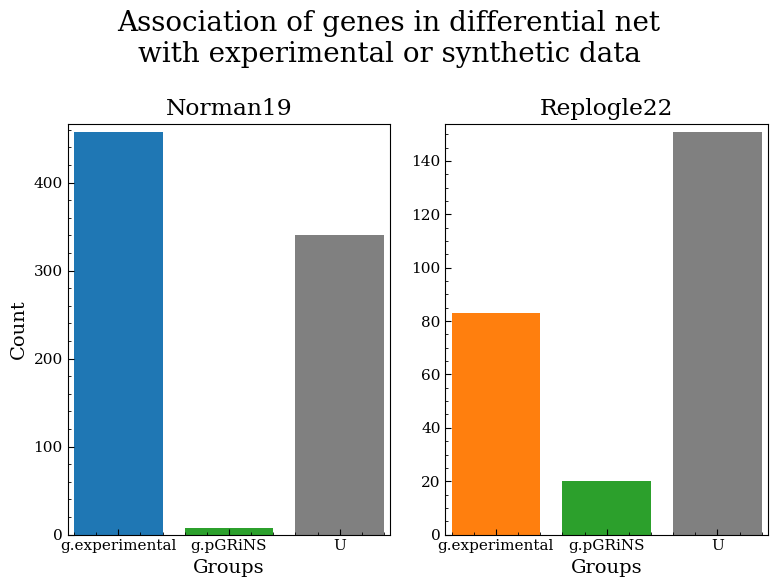

In [9]:
fig, axs = plt.subplots(1,2,figsize=(8,6))
for i in range(2):
    axs[i].bar(data[names[i]]["diffnet_genes"]["group"],data[names[i]]["diffnet_genes"]["count"],color=[prop_cycle[i],prop_cycle[2],"grey"])#,c=prop_cycle[i],s=1)
    axs[i].set_title(names[i])
    axs[i].set_xlabel(f"Groups")
axs[0].set_ylabel("Count")
fig.suptitle("Association of genes in differential net\nwith experimental or synthetic data")
plt.tight_layout()
plt.savefig(f"Plots/{grn_file}/001/diffnet_gene_bar.svg")
plt.show()

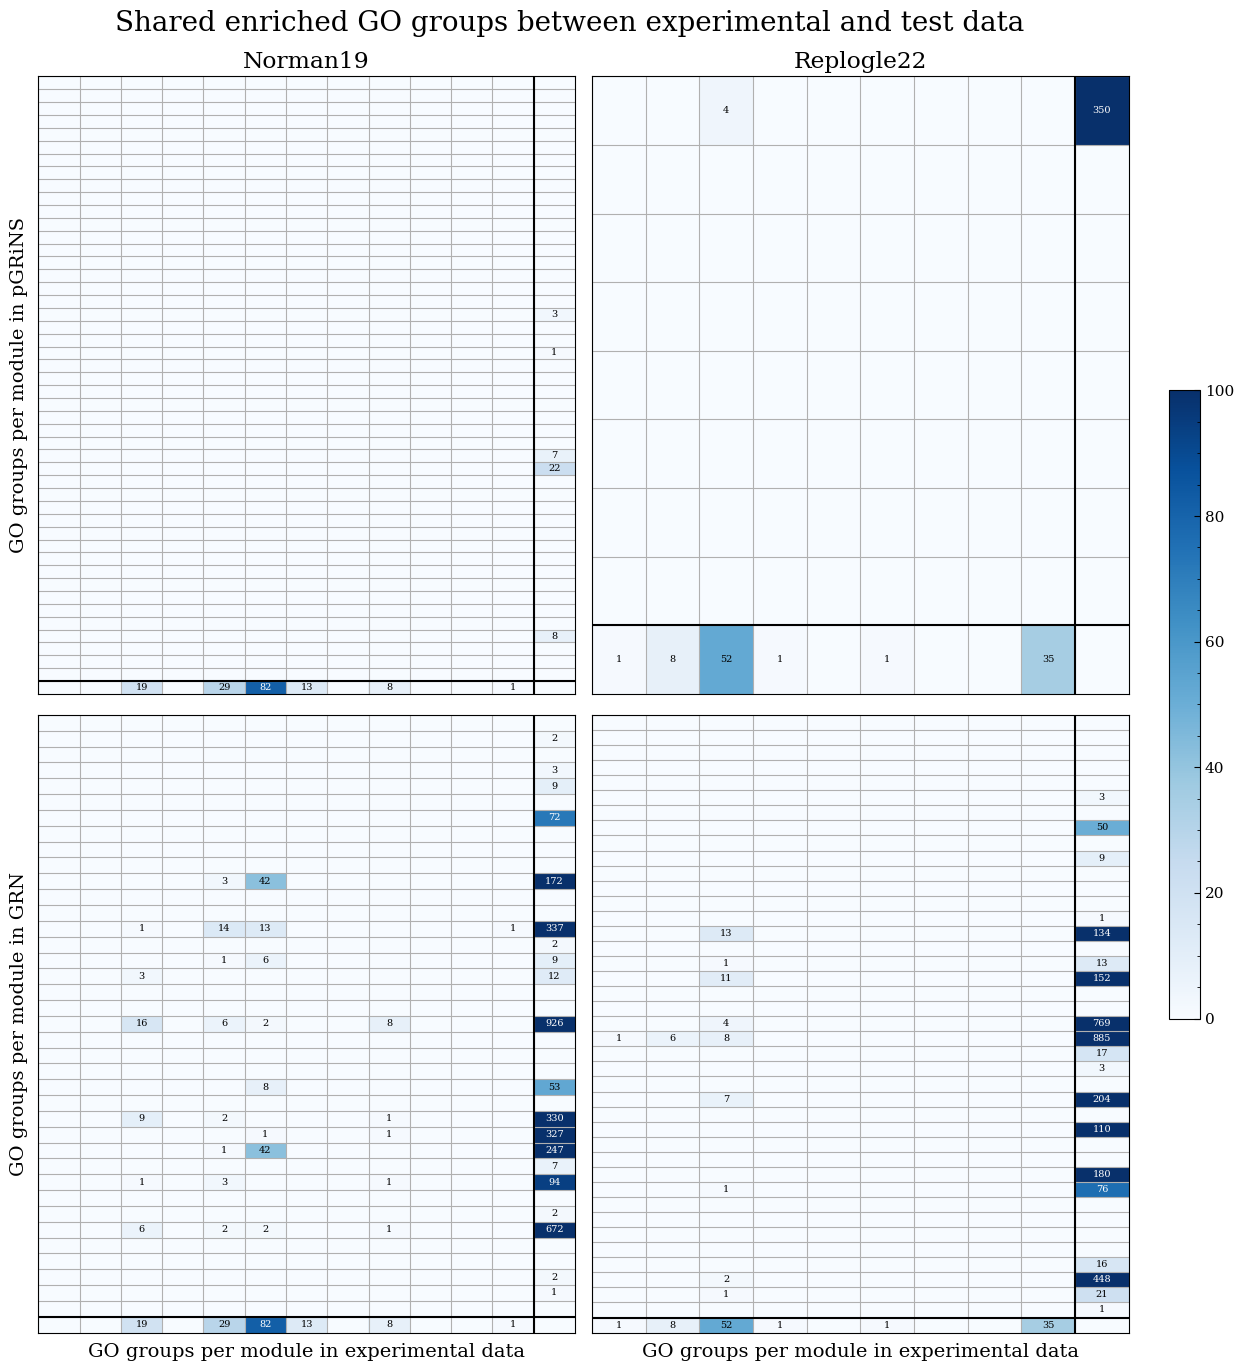

In [95]:
fig, axs = plt.subplots(2,2,figsize=(14,14))#,subplot_kw={"box_aspect":1})
mds = ["pGRiNS","GRN"]
vmax = 100
for j in range(2):
    x_height = np.max([data[names[j]][f"confusion_matrix_GRN"].shape[0],data[names[j]][f"confusion_matrix_pGRiNS"].shape[0]])
    #print(y_height)
    axs[0,j].set_title(names[j])
    for i in range(2):
        mat = data[names[j]][f"confusion_matrix_{mds[i]}"].T

        ax = axs[i,j]
        ax.set_xticks(ticks=[x-0.5 for x in range(mat.shape[1])])
        ax.set_yticks(ticks=[y-0.5 for y in range(mat.shape[0])])
        ax.tick_params(which="both",axis="both",length=0)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.hlines(-1.5+mat.shape[0],-0.5,-0.5+mat.shape[1],color="black")
        ax.vlines(-1.5+mat.shape[1],-0.5,-0.5+mat.shape[0],color="black")
        ax.grid()
        im = ax.imshow(mat,vmax=vmax,cmap="Blues",aspect="auto")#extent=((-0.5, x_height-0.5, mat.shape[0]-0.5, -0.5)))
        
        mat = np.asarray(mat)
        for k in range(mat.shape[0]):
            for l in range(mat.shape[1]):
                if mat[k,l]!=0:
                    if mat[k,l]>2*vmax/3:
                        color = "white"
                    else:
                        color = "black"
                    text = ax.text(l,k, mat[k, l],ha="center", va="center", color=color,size=7)
axs[0,0].set_ylabel("GO groups per module in pGRiNS")
axs[1,0].set_ylabel("GO groups per module in GRN")
axs[1,0].set_xlabel("GO groups per module in experimental data")
axs[1,1].set_xlabel("GO groups per module in experimental data")
fig.suptitle("Shared enriched GO groups between experimental and test data",x=0.415)
plt.tight_layout()
fig.colorbar(im,ax=axs.ravel().tolist(),pad=0.03,shrink=0.5)
plt.savefig(f"Plots/{grn_file}/001/confusion_matrix.svg")
plt.show()